# IoT Traffic Analysis: Flows vs Packets
This notebook compares two approaches for IoT device classification using the UNSW IoTraffic dataset:
1. **Flow-based Classification (ML):** Using statistical features from traffic flows with a Random Forest classifier.
2. **Packet-based Classification (DL):** Using raw packet bytes with a 1D Convolutional Neural Network (CNN).

In [1]:
# Install dependencies in the notebook environment
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


Install this to use GPU

In [2]:
%pip install "tensorflow[and-cuda]"

Note: you may need to restart the kernel to use updated packages.


In [23]:
# 1. Imports and Global Configuration
import os
import glob
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scapy.all import rdpcap

# ML/DL Libraries
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, MaxPooling1D, Flatten, Dropout
from tensorflow.keras.utils import to_categorical

# Configuration
DATA_FRAC = 0.1  # Use 100% of the dataset (or fraction like 0.1)
CANTIDAD_META = 1000000  # Target number of samples for both approaches
MAX_LEN = 500             # Max packet length for DL
MAX_PKTS_PER_FILE = 10000 # Limit packets read per file

# Paths
FLOW_DATA_PATH = 'flows/*.csv'
PCAP_DATA_PATH = 'pcaps/*.pcap'

print("Libraries imported and configuration set.")

Libraries imported and configuration set.


## GPU Configuration Check
TensorFlow automatically uses the GPU if it detects one. The following cell checks if a GPU is available and visible to TensorFlow.
**Note:** Scikit-learn (Random Forest) runs primarily on the CPU, but we use `n_jobs=-1` to utilize all CPU cores. The GPU will significantly speed up the CNN training in Section 3.

In [7]:
# Check for GPU availability
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        # Currently, memory growth needs to be the same across GPUs
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f" GPU Detected: {len(gpus)} device(s). TensorFlow will use it for the CNN.")
        
        # Print details
        for gpu in gpus:
            print(f"  - Name: {gpu.name}, Type: {gpu.device_type}")
            
    except RuntimeError as e:
        print(e)
else:
    print("⚠️ No GPU detected. The CNN will train on CPU (slower).")
    print("To enable GPU, ensure you have the NVIDIA drivers and CUDA Toolkit installed.")

 GPU Detected: 1 device(s). TensorFlow will use it for the CNN.
  - Name: /physical_device:GPU:0, Type: GPU


## 2. Flow-based Analysis (Machine Learning)
In this section, we load the CSV flow data, clean it by removing identifiers (IPs, MACs), and train a Random Forest classifier.

In [24]:
# Load and Clean Flow Data
print("\n--- [FLOWS] Loading Data ---")

file_paths = glob.glob(FLOW_DATA_PATH)
if not file_paths:
    print(f"Error: No CSVs found in {FLOW_DATA_PATH}")
else:
    df_list = []
    for fp in file_paths:
        df = pd.read_csv(fp, low_memory=False)
        device_name = os.path.basename(fp).split('.')[0] 
        df['device'] = device_name
        df_list.append(df)

    df_all = pd.concat(df_list, ignore_index=True)

    # Sampling
    if len(df_all) > CANTIDAD_META:
        print(f"Trimming Flows from {len(df_all)} to {CANTIDAD_META}...")
        df_all = df_all.sample(n=CANTIDAD_META, random_state=42)
    elif DATA_FRAC < 1.0:
        print(f"Sampling {DATA_FRAC*100}% of {len(df_all)} flows...")
        df_all = df_all.sample(frac=DATA_FRAC, random_state=42)

    print(f"Final dataset: {len(df_all)} flows from {df_all['device'].nunique()} devices.")

    # Cleaning
    drop_cols = ['time','srcMac','dstMac','ethType','srcIp','dstIp','ipProto','srcPort','dstPort','flowSeqNum']
    cols_to_drop = [c for c in drop_cols if c in df_all.columns]
    
    # Separate features and target
    X_flow = df_all.drop(columns=cols_to_drop + ['device'])
    y_flow = df_all['device']
    
    print("Data loaded and cleaned.")


--- [FLOWS] Loading Data ---
Trimming Flows from 4944041 to 1000000...
Final dataset: 1000000 flows from 27 devices.
Data loaded and cleaned.


In [18]:
# Train Random Forest Model
print("\n--- [FLOWS] Training Random Forest ---")

# Preprocessing Pipeline
cat_cols = X_flow.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X_flow.select_dtypes(include=['number']).columns.tolist()

preprocessor = ColumnTransformer(transformers=[
    ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols),
    ('scale', StandardScaler(), num_cols)
])

pipeline = Pipeline([
    ('preproc', preprocessor),
    ('rf', RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42))
])

# Split Data
X_train_flow, X_test_flow, y_train_flow, y_test_flow = train_test_split(X_flow, y_flow, test_size=0.3, stratify=y_flow, random_state=42)

# Train
start_time = time.time()
pipeline.fit(X_train_flow, y_train_flow)
time_flow = time.time() - start_time

# Evaluate
y_pred_flow = pipeline.predict(X_test_flow)
acc_flow = accuracy_score(y_test_flow, y_pred_flow)

print(f"--> [FLOWS] Finished. Time: {time_flow:.2f}s | Accuracy: {acc_flow:.4f}")


--- [FLOWS] Training Random Forest ---
--> [FLOWS] Finished. Time: 1.22s | Accuracy: 0.6991


## 3. Packet-based Analysis (Deep Learning)
In this section, we process raw PCAP files. We convert the first bytes of each packet into a numerical matrix and train a 1D CNN.

In [19]:
def pcap_to_matrix(file_path, max_len=MAX_LEN, data_frac=DATA_FRAC, max_pkts_read=MAX_PKTS_PER_FILE):
    """
    Reads a PCAP, converts packets to numeric arrays, and returns a sample.
    """
    try:
        # 1. Read packets (limited count)
        packets = rdpcap(file_path, count=max_pkts_read)
        
        raw_data = []
        
        # 2. Convert each packet to byte list
        for pkt in packets:
            byte_list = list(bytes(pkt))
            
            # Pad or Truncate
            if len(byte_list) > max_len:
                byte_list = byte_list[:max_len]
            else:
                byte_list = byte_list + [0] * (max_len - len(byte_list))
                
            raw_data.append(byte_list)
            
        data_array = np.array(raw_data)
        
        if len(data_array) == 0:
            return np.array([])

        # 3. Random Sampling
        n_keep = int(len(data_array) * data_frac)
        
        if n_keep > 0:
            indices = np.random.choice(len(data_array), n_keep, replace=False)
            return data_array[indices]
        else:
            return np.array([])

    except Exception as e:
        print(f"Error reading {file_path}: {e}")
        return np.array([])

print("Helper function defined.")

Helper function defined.


In [20]:
# Load and Preprocess Packet Data
print(f"\n--- [PACKETS] Loading Data (Target: {CANTIDAD_META} samples) ---")

files = glob.glob(PCAP_DATA_PATH)
X_list, y_list = [], []

print("Processing PCAPs...")
for f in files:
    label = os.path.basename(f).split('.')[0]
    data = pcap_to_matrix(f)
    if len(data) > 0:
        X_list.append(data)
        y_list.extend([label] * len(data))
        
if not X_list:
    print("Error: No packet data found.")
else:
    X_pcap = np.concatenate(X_list)
    y_labels_pcap = np.array(y_list) 

    # Trim to match Flow dataset size
    if len(X_pcap) > CANTIDAD_META:
        print(f"Trimming Packets from {len(X_pcap)} to {CANTIDAD_META}...")
        indices = np.random.choice(len(X_pcap), CANTIDAD_META, replace=False)
        X_pcap = X_pcap[indices]
        y_labels_pcap = y_labels_pcap[indices]

    # Normalize
    X_pcap = X_pcap / 255.0 
    
    # Encode Labels
    le = LabelEncoder()
    y_integers = le.fit_transform(y_labels_pcap)
    y_onehot = to_categorical(y_integers)
    
    # Reshape for CNN (samples, timesteps, features)
    X_pcap = X_pcap.reshape(X_pcap.shape[0], X_pcap.shape[1], 1)
    
    print(f"Packet data ready. Shape: {X_pcap.shape}")


--- [PACKETS] Loading Data (Target: 100000 samples) ---
Processing PCAPs...
Packet data ready. Shape: (24574, 500, 1)


In [21]:
# Train CNN Model
print("\n--- [PACKETS] Training CNN ---")

# Split
X_train_pcap, X_test_pcap, y_train_pcap, y_test_pcap = train_test_split(X_pcap, y_onehot, test_size=0.3, random_state=42)

# Define Model
model = Sequential([
    Conv1D(32, 3, activation='relu', input_shape=(MAX_LEN, 1)),
    MaxPooling1D(2),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(len(le.classes_), activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print(f"Training CNN with {len(X_train_pcap)} samples...")
start_time = time.time()

# Train
history = model.fit(X_train_pcap, y_train_pcap, epochs=5, batch_size=32, verbose=1)

time_pcap = time.time() - start_time

# Evaluate
loss, acc_pcap = model.evaluate(X_test_pcap, y_test_pcap, verbose=0)
print(f"--> [PACKETS] Finished. Time: {time_pcap:.2f}s | Accuracy: {acc_pcap:.4f}")


--- [PACKETS] Training CNN ---


/media/orb/SSD 1TB1/TMA/UNSW-IoTraffic/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1767709573.251575    4991 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6361 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2080, pci bus id: 0000:09:00.0, compute capability: 7.5


Training CNN with 17201 samples...
Epoch 1/5


2026-01-06 15:26:15.103541: I external/local_xla/xla/service/service.cc:163] XLA service 0x7973d0205f20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-01-06 15:26:15.103564: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 2080, Compute Capability 7.5
2026-01-06 15:26:15.162461: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-01-06 15:26:15.362872: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91701


 58/538 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0684 - loss: 3.1844

I0000 00:00:1767709577.001647    8449 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


538/538 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.4215 - loss: 2.0303
Epoch 2/5
538/538 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7236 - loss: 0.9051
Epoch 3/5
538/538 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8125 - loss: 0.5753
Epoch 4/5
538/538 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8469 - loss: 0.4423
Epoch 5/5
538/538 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8691 - loss: 0.3644
--> [PACKETS] Finished. Time: 10.80s | Accuracy: 0.9483


## 4. Comparative Analysis
Here we visualize the performance differences between the Flow-based (ML) and Packet-based (DL) approaches.

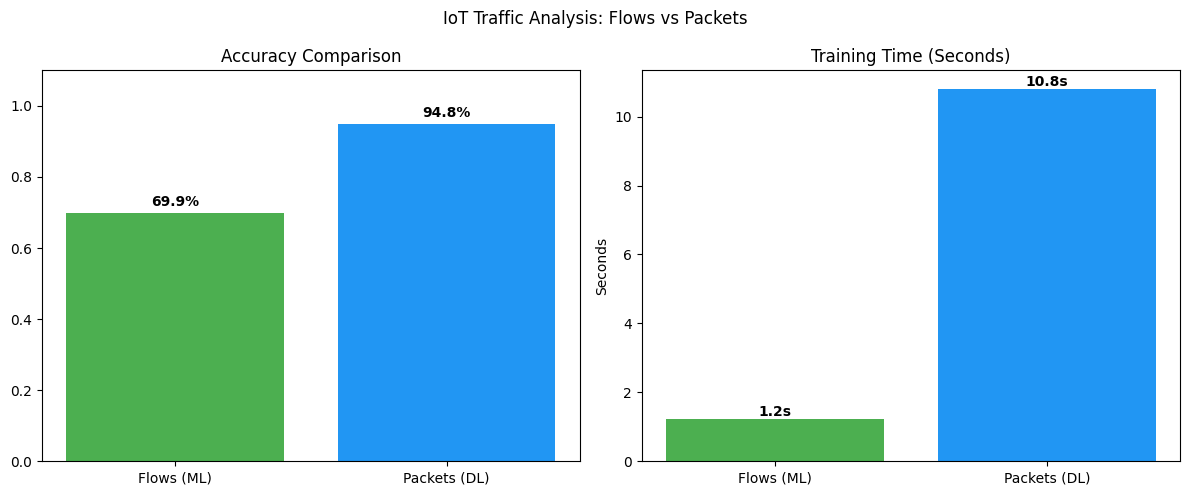

In [22]:
# Visualization
labels = ['Flows (ML)', 'Packets (DL)']
accuracies = [acc_flow, acc_pcap]
times = [time_flow, time_pcap]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Accuracy Plot
ax1.bar(labels, accuracies, color=['#4CAF50', '#2196F3'])
ax1.set_title('Accuracy Comparison')
ax1.set_ylim(0, 1.1)
for i, v in enumerate(accuracies):
    ax1.text(i, v + 0.02, f"{v*100:.1f}%", ha='center', fontweight='bold')

# Time Plot
ax2.bar(labels, times, color=['#4CAF50', '#2196F3'])
ax2.set_title('Training Time (Seconds)')
ax2.set_ylabel('Seconds')
for i, v in enumerate(times):
    ax2.text(i, v, f"{v:.1f}s", ha='center', va='bottom', fontweight='bold')

plt.suptitle('IoT Traffic Analysis: Flows vs Packets')
plt.tight_layout()
plt.show()